In [2]:
import qiskit

# ***The Bernstein-Vazirani Algorithm***

## 1. The Secret Password

Imagine a Black Box (Oracle) that contains a secret binary string, let's call it $s$. For example, $s = 1011$.
The Black Box takes an input $x$, calculates the bitwise dot product with $s$ modulo 2, and outputs the result:


$$f(x) = x \cdot s \pmod{2}$$

**The Challenge:**
How many times do we need to query the Black Box to find the secret string $s$?

* **Classical Computer:** It must guess one bit at a time. It sends $1000$ to find the first bit, $0100$ for the second, and so on. If the string is $n$ bits long, it takes exactly **$n$ tries**.
* **Quantum Computer:** Using the BV algorithm, we can find the *entire* secret string $s$ in exactly **ONE single try**, even if the password is a million bits long!

**How it works:**
We use the exact same circuit structure as Deutsch-Jozsa! We put all input qubits in superposition, set the output qubit to $\vert{}-\rangle$, and apply the Oracle. Through the magic of **Phase Kickback**, the Oracle kicks the phase of the '1's in the secret string back onto our input qubits. When we apply H-gates again, the interference perfectly reconstructs the secret string $s$.

---

## 2. Guessing a Secret String in One Shot

Let's build a circuit to find the secret string `1011`.



Bernstein-Vazirani Circuit for secret '100101':


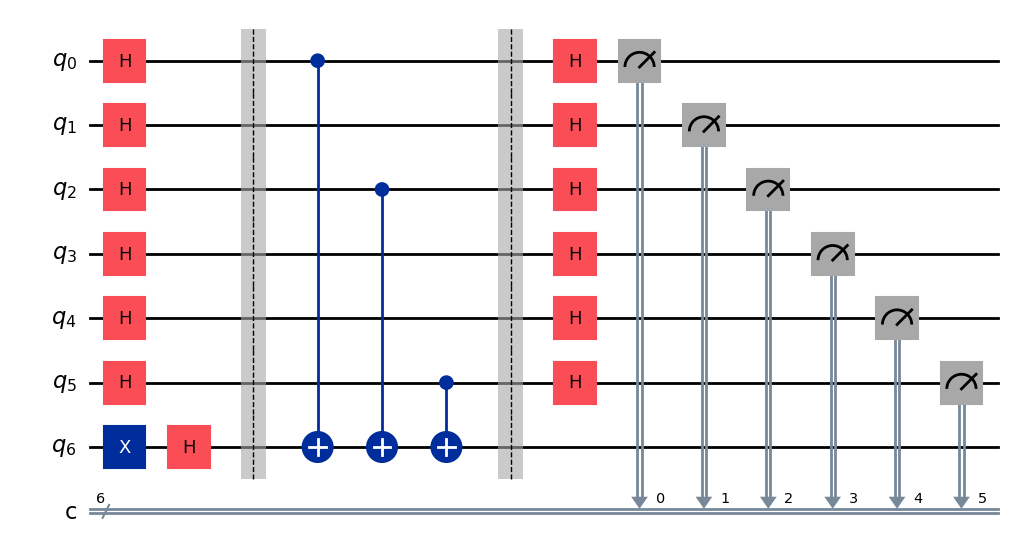


Measurement Result: {'100101': 1}


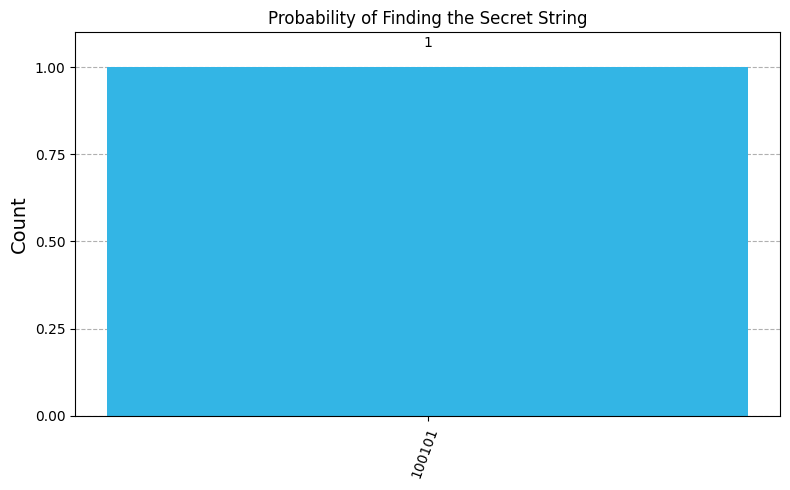

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# The secret string we want the quantum computer to find
secret_string = '100101'
n = len(secret_string)

# --- Step 1: Initialize Circuit ---
# n qubits for the input, 1 for the output, and n classical bits for measurement
qc = QuantumCircuit(n + 1, n)

# --- Step 2: Setup the Qubits ---
for i in range(n):
    qc.h(i)

# Set the output qubit to |-> for Phase Kickback
qc.x(n)
qc.h(n)

qc.barrier()

# --- Step 3: THE ORACLE (The Black Box) ---
# The oracle applies a CNOT gate for every '1' in the secret string.
# Qiskit reads strings right-to-left, so we reverse it to match qubit indices.
for i, bit in enumerate(secret_string[::-1]):
    if bit == '1':
        qc.cx(i, n)

qc.barrier()

# --- Step 4: Interference and Measurement ---
for i in range(n):
    qc.h(i)

for i in range(n):
    qc.measure(i, i)

# --- Visualize Circuit ---
print(f"Bernstein-Vazirani Circuit for secret '{secret_string}':")
display(qc.draw('mpl'))

# --- Simulate ---
sim = AerSimulator()
result = sim.run(qc, shots=1).result() # ONE SHOT!
counts = result.get_counts()

print("\nMeasurement Result:", counts)

# --- Visualization (Like your image!) ---
fig = plot_histogram(
    counts, 
    title="Probability of Finding the Secret String", 
    figsize=(8, 5), 
    color='#33b5e5' # That vibrant blue you like
)
display(fig)

## 3. Exercises (Hands-on Practice)

### Exercise 1: Change the Secret

**Goal:** Prove that the algorithm works for any string length and combination.

* **Task:** Change `secret_string = '1011'` to something longer, like `'1100101'`.
* **Observation:** Run the code again. Notice that `n` automatically updates, the circuit gets larger, but the simulator *still* finds the exact string in just `shots=1`. Your histogram should show a single bar at 100% for `1100101`.

### Exercise 2: The "Zero" Edge Case

**Goal:** Understand what happens when the secret string has no '1's.

* **Task:** Set `secret_string = '000'`. Look at the Oracle section of the drawn circuit. What do you notice?
* **Explanation:** Because there are no '1's, the Oracle is completely empty! No CNOT gates are applied. The H-gates simply cancel each other out, and you measure exactly `000`.

---

Bhai, now that we have conquered Deutsch, Deutsch-Jozsa, and Bernstein-Vazirani, we have perfectly built up the concepts of Oracles and Phase Kickback. Are you ready to finally dive into the most famous algorithm of them all: **Grover's Search Algorithm**?